# 02 — Metric Decomposition Analysis

**Manuscript section:** Results §2 — *Geometric metrics capture distinct outlier classes*

**Purpose:** Characterise the correlation structure, redundancy, and biological meaning of the four geometric metrics (L2 norm, centroid distance, cosine similarity, isolation score) used to define the composite anomaly score.

**Inputs:** `data/Table_S1.csv` (18,915 shared genes × 3 models × 4 metrics + annotations)

**Outputs:**
- `figs/metric_decomposition.pdf` — Main figure (panels a–f)
- `data/metric_decomposition_summary.csv` — Per-gene metric-category assignments

**Key findings:**
1. L2 norm and centroid distance are highly redundant (ρ≥0.54 across models)
2. Isolation score and cosine similarity capture independent phenomena
3. Magnitude outliers (norm/distance) are housekeeping genes; isolation outliers are tissue-restricted
4. The composite max-z approach is justified: single metrics miss 38–69% of outliers

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from glitch_style import *

# Additional colours for this analysis
NORM_COLOR = '#E05A4F'    # Red — magnitude axis
ISO_COLOR  = '#4682B4'    # Blue — isolation axis
COS_COLOR  = '#2CA02C'    # Green — cosine axis
MULTI_COLOR = '#FFB347'   # Orange — multi-metric
SF_COLOR   = '#9B59B6'    # Purple — scFoundation

In [2]:
# ── Load data ────────────────────────────────────────────────────────
ts1 = pd.read_csv('data/Table_S1.csv')
print(f'Loaded: {ts1.shape[0]:,} genes × {ts1.shape[1]} columns')

# Define metric columns per model (z-scored)
models = {
    'Geneformer':    {'norm': 'gf_norm', 'dist': 'gf_dist', 'cos': 'gf_cos', 'iso': 'gf_isolation'},
    'scGPT':         {'norm': 'scgpt_norm', 'dist': 'scgpt_dist', 'cos': 'scgpt_cos', 'iso': 'scgpt_isolation'},
    'scFoundation':  {'norm': 'sf_norm', 'dist': 'sf_dist', 'cos': 'sf_cos', 'iso': 'sf_isolation'},
}

metric_labels = {'norm': 'L2 norm', 'dist': 'Centroid dist.', 'cos': 'Cosine sim.', 'iso': 'Isolation'}
THRESHOLD = 3.0

Loaded: 18,915 genes × 30 columns


In [3]:
# ══════════════════════════════════════════════════════════════════════
# ANALYSIS 1: Pairwise Spearman correlations between z-scored metrics
# ══════════════════════════════════════════════════════════════════════
labels = ['Norm', 'Dist', 'Cos', 'Iso']
corr_matrices = {}

for model_name, cols in models.items():
    metric_cols = list(cols.values())
    data = ts1[metric_cols].dropna()
    corr = data.corr(method='spearman')
    corr.index = labels
    corr.columns = labels
    corr_matrices[model_name] = corr
    
    print(f'\n{model_name} (n={len(data):,}):')
    print(corr.round(3).to_string())
    
    # Highlight key pairs
    rho_nd = corr.loc['Norm', 'Dist']
    rho_ni = corr.loc['Norm', 'Iso']
    rho_di = corr.loc['Dist', 'Iso']
    rho_ci = corr.loc['Cos', 'Iso']
    print(f'  Norm–Dist: ρ={rho_nd:.3f} (redundancy axis)')
    print(f'  Norm–Iso:  ρ={rho_ni:.3f}')
    print(f'  Dist–Iso:  ρ={rho_di:.3f}')
    print(f'  Cos–Iso:   ρ={rho_ci:.3f}')


Geneformer (n=18,915):
       Norm   Dist    Cos    Iso
Norm  1.000  0.956  0.150  0.534
Dist  0.956  1.000 -0.109  0.694
Cos   0.150 -0.109  1.000 -0.544
Iso   0.534  0.694 -0.544  1.000
  Norm–Dist: ρ=0.956 (redundancy axis)
  Norm–Iso:  ρ=0.534
  Dist–Iso:  ρ=0.694
  Cos–Iso:   ρ=-0.544

scGPT (n=18,915):
       Norm   Dist    Cos    Iso
Norm  1.000  0.542 -0.225 -0.022
Dist  0.542  1.000 -0.909  0.211
Cos  -0.225 -0.909  1.000 -0.335
Iso  -0.022  0.211 -0.335  1.000
  Norm–Dist: ρ=0.542 (redundancy axis)
  Norm–Iso:  ρ=-0.022
  Dist–Iso:  ρ=0.211
  Cos–Iso:   ρ=-0.335

scFoundation (n=18,915):
       Norm   Dist    Cos    Iso
Norm  1.000  1.000  0.010 -0.004
Dist  1.000  1.000 -0.002 -0.003
Cos   0.010 -0.002  1.000 -0.080
Iso  -0.004 -0.003 -0.080  1.000
  Norm–Dist: ρ=1.000 (redundancy axis)
  Norm–Iso:  ρ=-0.004
  Dist–Iso:  ρ=-0.003
  Cos–Iso:   ρ=-0.080


In [4]:
# ══════════════════════════════════════════════════════════════════════
# ANALYSIS 2: PCA — effective dimensionality
# ══════════════════════════════════════════════════════════════════════
pca_results = {}

for model_name, cols in models.items():
    metric_cols = list(cols.values())
    data = ts1[metric_cols].dropna()
    X = StandardScaler().fit_transform(data)
    pca = PCA(n_components=4)
    pca.fit(X)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    n_95 = int(np.searchsorted(cum_var, 0.95) + 1)
    
    pca_results[model_name] = {
        'var_ratio': pca.explained_variance_ratio_,
        'cum_var': cum_var,
        'n_95': n_95,
        'loadings': pd.DataFrame(pca.components_.T,
                                  index=['Norm', 'Dist', 'Cos', 'Iso'],
                                  columns=[f'PC{i+1}' for i in range(4)])
    }
    
    print(f'\n{model_name}:')
    print(f'  Variance: {["{:.1%}".format(v) for v in pca.explained_variance_ratio_]}')
    print(f'  Cumulative: {["{:.1%}".format(v) for v in cum_var]}')
    print(f'  Components for >95% variance: {n_95}')
    print(f'  PC1 loadings: {dict(pca_results[model_name]["loadings"]["PC1"].round(3))}')
    print(f'  PC2 loadings: {dict(pca_results[model_name]["loadings"]["PC2"].round(3))}')


Geneformer:
  Variance: ['61.7%', '34.0%', '4.3%', '0.0%']
  Cumulative: ['61.7%', '95.7%', '100.0%', '100.0%']
  Components for >95% variance: 2
  PC1 loadings: {'Norm': np.float64(0.538), 'Dist': np.float64(0.598), 'Cos': np.float64(-0.269), 'Iso': np.float64(0.53)}
  PC2 loadings: {'Norm': np.float64(0.456), 'Dist': np.float64(0.275), 'Cos': np.float64(0.749), 'Iso': np.float64(-0.394)}

scGPT:
  Variance: ['54.8%', '30.9%', '14.3%', '0.0%']
  Cumulative: ['54.8%', '85.7%', '100.0%', '100.0%']
  Components for >95% variance: 3
  PC1 loadings: {'Norm': np.float64(0.447), 'Dist': np.float64(0.675), 'Cos': np.float64(-0.58), 'Iso': np.float64(0.096)}
  PC2 loadings: {'Norm': np.float64(-0.531), 'Dist': np.float64(-0.028), 'Cos': np.float64(-0.311), 'Iso': np.float64(0.788)}

scFoundation:
  Variance: ['50.0%', '27.1%', '22.9%', '0.0%']
  Cumulative: ['50.0%', '77.1%', '100.0%', '100.0%']
  Components for >95% variance: 3
  PC1 loadings: {'Norm': np.float64(0.707), 'Dist': np.float64(0

In [5]:
# ══════════════════════════════════════════════════════════════════════
# ANALYSIS 3: Single-metric outlier decomposition
# ══════════════════════════════════════════════════════════════════════
outlier_analysis = {}

for model_name, cols in models.items():
    data = ts1[list(cols.values()) + ['gene_symbol']].dropna()
    
    # Per-metric outlier sets
    outlier_sets = {}
    for short_name, col in cols.items():
        outlier_sets[short_name] = set(data.loc[data[col].abs() > THRESHOLD, 'gene_symbol'])
    
    # Composite
    composite_z = data[list(cols.values())].abs().max(axis=1)
    composite = set(data.loc[composite_z > THRESHOLD, 'gene_symbol'])
    
    # Categorise outliers by driving metric(s)
    categories = {}
    for gene in composite:
        flags = {k: gene in oset for k, oset in outlier_sets.items()}
        n_flags = sum(flags.values())
        if n_flags == 1:
            driving = [k for k, v in flags.items() if v][0]
            if driving in ('norm', 'dist'):
                categories[gene] = 'magnitude'
            elif driving == 'iso':
                categories[gene] = 'isolation'
            elif driving == 'cos':
                categories[gene] = 'cosine'
        elif all(flags[k] for k in ['norm', 'dist']) and not flags['iso'] and not flags['cos']:
            categories[gene] = 'magnitude'
        else:
            categories[gene] = 'multiple'
    
    print(f'\n{model_name}: {len(composite)} total outliers')
    for cat in ['magnitude', 'isolation', 'cosine', 'multiple']:
        n = sum(1 for c in categories.values() if c == cat)
        pct = n / len(composite) * 100
        print(f'  {cat}: {n} ({pct:.1f}%)')
    
    # Jaccard between norm and distance
    s_n, s_d = outlier_sets['norm'], outlier_sets['dist']
    jacc_nd = len(s_n & s_d) / len(s_n | s_d) if len(s_n | s_d) > 0 else 0
    print(f'  Norm–Dist Jaccard: {jacc_nd:.3f}')
    
    # Jaccard between magnitude (norm∪dist) and isolation
    s_mag = s_n | s_d
    s_iso = outlier_sets['iso']
    jacc_mi = len(s_mag & s_iso) / len(s_mag | s_iso) if len(s_mag | s_iso) > 0 else 0
    print(f'  Magnitude–Isolation Jaccard: {jacc_mi:.3f}')
    
    outlier_analysis[model_name] = {
        'outlier_sets': outlier_sets,
        'composite': composite,
        'categories': categories,
    }


Geneformer: 388 total outliers
  magnitude: 322 (83.0%)
  isolation: 60 (15.5%)
  cosine: 0 (0.0%)
  multiple: 6 (1.5%)
  Norm–Dist Jaccard: 0.730
  Magnitude–Isolation Jaccard: 0.010

scGPT: 102 total outliers
  magnitude: 72 (70.6%)
  isolation: 10 (9.8%)
  cosine: 6 (5.9%)
  multiple: 14 (13.7%)
  Norm–Dist Jaccard: 0.035
  Magnitude–Isolation Jaccard: 0.083

scFoundation: 161 total outliers
  magnitude: 52 (32.3%)
  isolation: 48 (29.8%)
  cosine: 61 (37.9%)
  multiple: 0 (0.0%)
  Norm–Dist Jaccard: 0.962
  Magnitude–Isolation Jaccard: 0.000


In [6]:
# ══════════════════════════════════════════════════════════════════════
# ANALYSIS 4: Biological characterization of metric-specific outliers
# ══════════════════════════════════════════════════════════════════════

# Focus on Geneformer (richest biological signal)
gf_cats = outlier_analysis['Geneformer']['categories']
ts1['gf_metric_category'] = ts1['gene_symbol'].map(gf_cats).fillna('non-outlier')

bio_cols = ['max_tpm', 'expression_breadth', 'pLI', 'gene_length_bp', 'clinvar_disease', 'biotype']

for cat in ['magnitude', 'isolation', 'cosine', 'multiple', 'non-outlier']:
    subset = ts1[ts1['gf_metric_category'] == cat]
    if len(subset) == 0:
        continue
    print(f'\n{cat.upper()} outliers (n={len(subset)}):')
    for col in ['max_tpm', 'expression_breadth', 'pLI', 'gene_length_bp']:
        if col in subset.columns:
            v = subset[col].dropna()
            print(f'  {col}: median={v.median():.3f}')
    if 'clinvar_disease' in subset.columns:
        frac = subset['clinvar_disease'].mean()
        print(f'  ClinVar disease fraction: {frac:.3f}')
    # Top 5 genes
    top = subset.nlargest(5, 'gf_anomaly_score')['gene_symbol'].tolist()
    print(f'  Top genes: {", ".join(top)}')

# Statistical comparisons
print('\n--- Statistical tests (magnitude vs isolation outliers) ---')
mag = ts1[ts1['gf_metric_category'] == 'magnitude']
iso = ts1[ts1['gf_metric_category'] == 'isolation']
for col in ['max_tpm', 'expression_breadth', 'pLI', 'gene_length_bp']:
    m_vals = mag[col].dropna()
    i_vals = iso[col].dropna()
    if len(m_vals) > 3 and len(i_vals) > 3:
        stat, pval = stats.mannwhitneyu(m_vals, i_vals, alternative='two-sided')
        print(f'  {col}: magnitude median={m_vals.median():.3f} vs isolation median={i_vals.median():.3f}, MWU p={pval:.2e}')


MAGNITUDE outliers (n=322):
  max_tpm: median=1322.750
  expression_breadth: median=1.000
  pLI: median=0.745
  gene_length_bp: median=12497.500
  ClinVar disease fraction: 0.556
  Top genes: RBFOX1, KCNIP4, MAGI2, ST18, B2M

ISOLATION outliers (n=60):
  max_tpm: median=0.100
  expression_breadth: median=0.000
  pLI: median=0.053
  gene_length_bp: median=5947.500
  ClinVar disease fraction: 0.033
  Top genes: OR7A10, OR8H1, OR6C1, OR10H3, OR4P4

MULTIPLE outliers (n=6):
  max_tpm: median=1110.700
  expression_breadth: median=1.000
  pLI: median=0.313
  gene_length_bp: median=5299.500
  ClinVar disease fraction: 0.500
  Top genes: FTH1, FTL, RPS26, SAT1, OR5H1

NON-OUTLIER outliers (n=18527):
  max_tpm: median=41.400
  expression_breadth: median=0.980
  pLI: median=0.000
  gene_length_bp: median=28108.000
  ClinVar disease fraction: 0.437
  Top genes: CHRM3, LGALS4, OR2D3, MT-CYB, SPRR3

--- Statistical tests (magnitude vs isolation outliers) ---
  max_tpm: magnitude median=1322.750 vs

In [7]:
# ══════════════════════════════════════════════════════════════════════
# ANALYSIS 5: Detailed metric-specific gene lists
# ══════════════════════════════════════════════════════════════════════

gf_cols = models['Geneformer']
data = ts1.copy()

# Isolation-only outliers in Geneformer
iso_only = data[(data['gf_metric_category'] == 'isolation')].sort_values('gf_anomaly_score', ascending=False)
print(f'Geneformer isolation-only outliers: {len(iso_only)}')
print(iso_only[['gene_symbol', 'gf_anomaly_score', 'gf_isolation', 'gf_norm', 'max_tpm', 'pLI', 'biotype']].head(15).to_string())

# Magnitude-only outliers in Geneformer
mag_only = data[data['gf_metric_category'] == 'magnitude'].sort_values('gf_anomaly_score', ascending=False)
print(f'\nGeneformer magnitude-only outliers: {len(mag_only)}')
print(mag_only[['gene_symbol', 'gf_anomaly_score', 'gf_norm', 'gf_dist', 'max_tpm', 'pLI', 'biotype']].head(15).to_string())

# scGPT isolation-only
scgpt_cats = outlier_analysis['scGPT']['categories']
data['scgpt_metric_category'] = data['gene_symbol'].map(scgpt_cats).fillna('non-outlier')
scgpt_iso = data[data['scgpt_metric_category'] == 'isolation'].sort_values('scgpt_anomaly_score', ascending=False)
print(f'\nscGPT isolation-only outliers: {len(scgpt_iso)}')
print(scgpt_iso[['gene_symbol', 'scgpt_anomaly_score', 'scgpt_isolation', 'max_tpm', 'biotype']].head(10).to_string())

Geneformer isolation-only outliers: 60
    gene_symbol  gf_anomaly_score  gf_isolation   gf_norm  max_tpm       pLI         biotype
181      OR7A10          3.425875     -3.425875  0.574303      0.0  0.336970  protein_coding
185       OR8H1          3.417590     -3.417590  0.355592      0.1  0.340840  protein_coding
192       OR6C1          3.409077     -3.409077  0.210637      0.0  0.292970  protein_coding
193      OR10H3          3.405086     -3.405086  0.350111      0.0  0.000002  protein_coding
212       OR4P4          3.346392     -3.346392  0.647178      0.3       NaN  protein_coding
213       OR4Q3          3.343786     -3.343786  0.599630      0.1       NaN  protein_coding
216      TAS1R2          3.334170     -3.334170  0.466206      0.1       NaN  protein_coding
220       OR6C6          3.326663     -3.326663  0.739001      0.2       NaN  protein_coding
224       OR6B1          3.305601     -3.305601  0.733858      0.4  0.000008  protein_coding
228       OR4D2          3.3004

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Saved: figs/Fig2_metric_decomposition.pdf, figs/Fig2_metric_decomposition.png


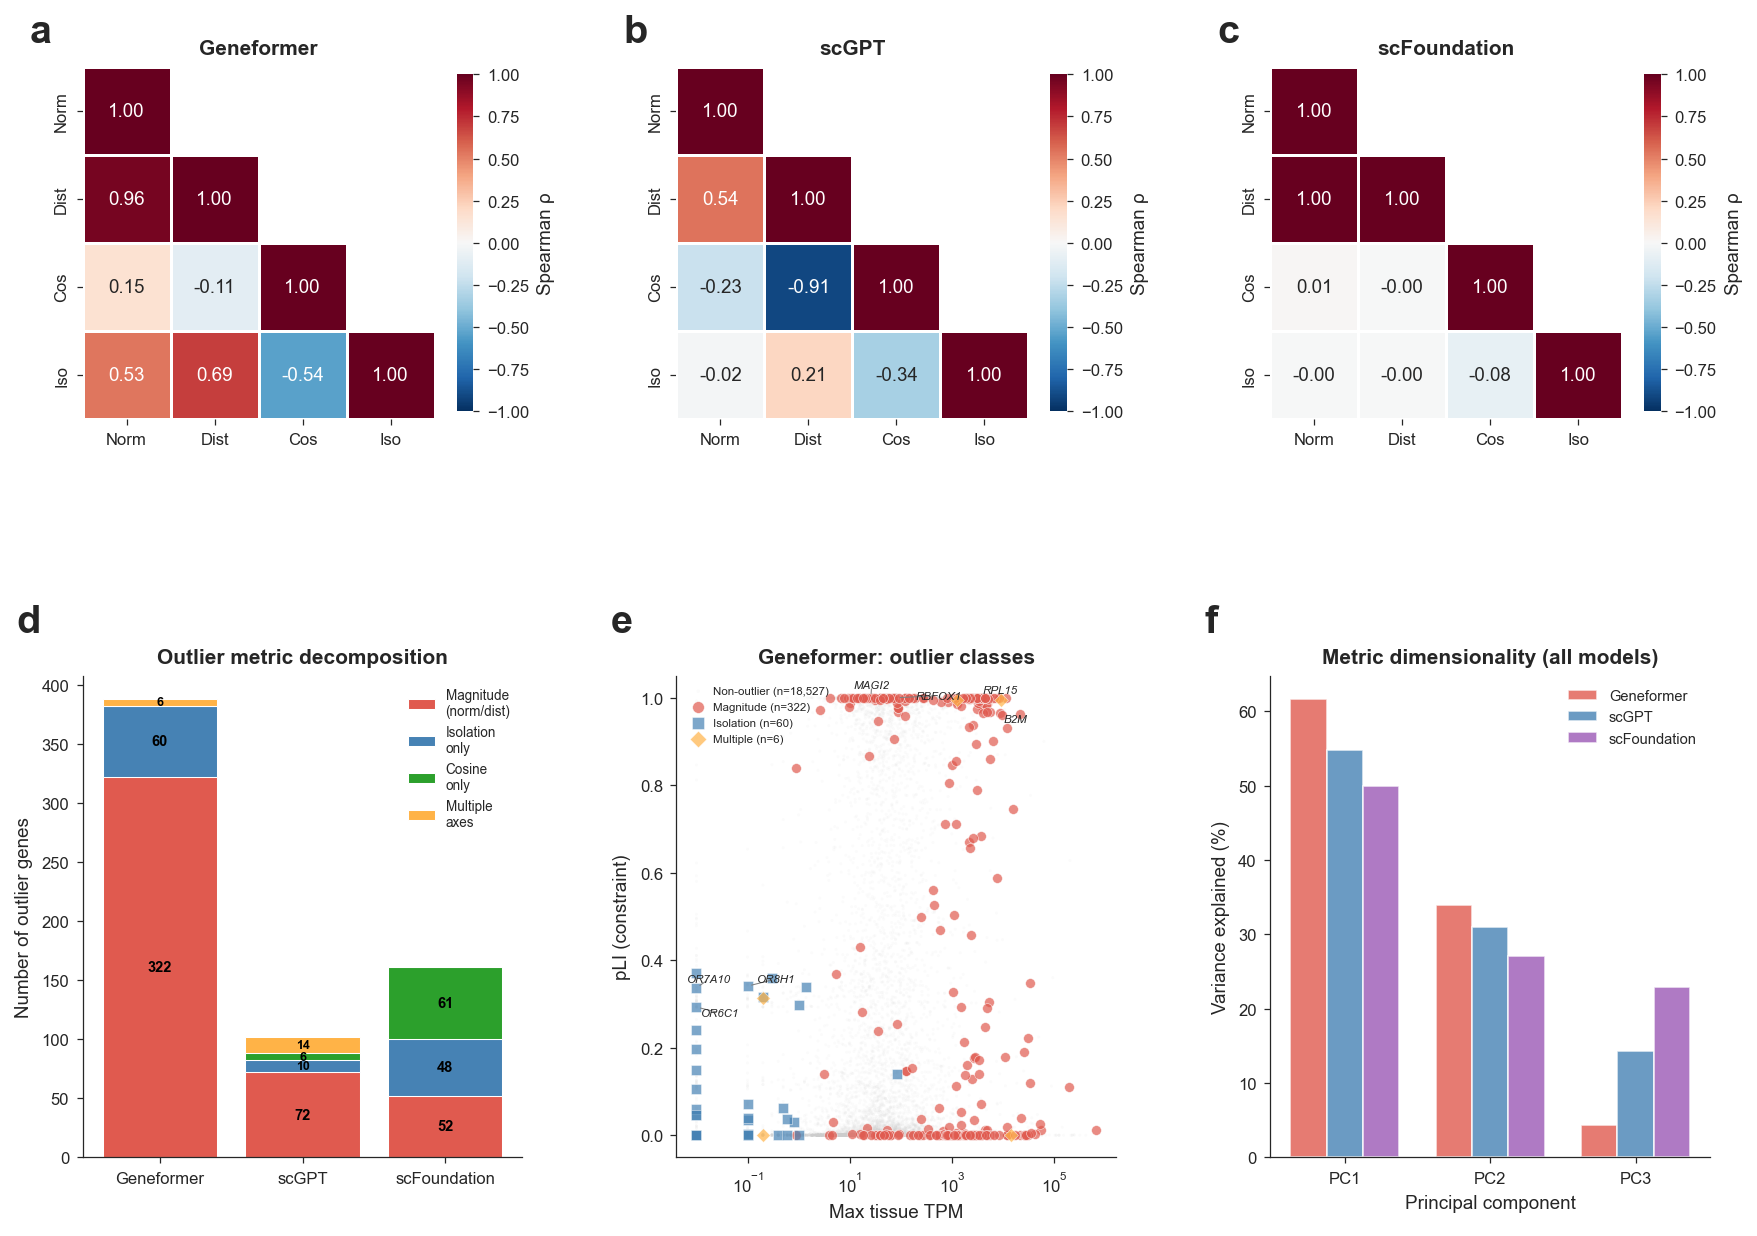

In [8]:
# ══════════════════════════════════════════════════════════════════════
# FIGURE: Metric decomposition (6 panels)
# ══════════════════════════════════════════════════════════════════════
from adjustText import adjust_text

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# ── Panels a–c: Correlation heatmaps ──
model_names = ['Geneformer', 'scGPT', 'scFoundation']
hm_labels = ['Norm', 'Dist', 'Cos', 'Iso']

for idx, model_name in enumerate(model_names):
    ax = fig.add_subplot(gs[0, idx])
    corr = corr_matrices[model_name]
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.7, 'label': 'Spearman \u03c1'}, ax=ax)
    ax.set_title(model_name, fontweight='bold')
    ax.text(-0.15, 1.15, chr(ord('a') + idx), transform=ax.transAxes,
            fontsize=19, fontweight='bold', va='top')

# ── Panel d: Metric contribution stacked bars ──
ax_d = fig.add_subplot(gs[1, 0])

cats_order = ['magnitude', 'isolation', 'cosine', 'multiple']
cat_labels = ['Magnitude\n(norm/dist)', 'Isolation\nonly', 'Cosine\nonly', 'Multiple\naxes']
cat_colors = [NORM_COLOR, ISO_COLOR, COS_COLOR, MULTI_COLOR]

bottom = np.zeros(len(model_names))
for cat, label, color in zip(cats_order, cat_labels, cat_colors):
    vals = []
    for mn in model_names:
        n = sum(1 for c in outlier_analysis[mn]['categories'].values() if c == cat)
        vals.append(n)
    bars = ax_d.bar(model_names, vals, bottom=bottom, color=color,
                    label=label, edgecolor='white', linewidth=0.5)
    for j, v in enumerate(vals):
        bar_centre_y = bottom[j] + v / 2
        if v >= 15:
            # Comfortable bar: black text inside
            ax_d.text(j, bar_centre_y, str(v), ha='center', va='center',
                     fontsize=7, color='black', fontweight='bold')
        elif v >= 5:
            # Smaller bar: black text inside, slightly smaller font
            ax_d.text(j, bar_centre_y, str(v), ha='center', va='center',
                     fontsize=6, color='black', fontweight='bold')
        elif v > 0:
            # Tiny bar: floating label with leader line, black text
            ax_d.annotate(
                str(v),
                xy=(j, bar_centre_y),
                xytext=(j + 0.38, bar_centre_y),
                fontsize=6, fontweight='bold', color='black',
                ha='left', va='center',
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8),
            )
    bottom += vals

ax_d.set_ylabel('Number of outlier genes')
ax_d.legend(loc='upper right', fontsize=6.5, framealpha=0.9)
ax_d.set_title('Outlier metric decomposition', fontweight='bold')
ax_d.text(-0.15, 1.15, 'd', transform=ax_d.transAxes,
          fontsize=19, fontweight='bold', va='top')
sns.despine(ax=ax_d)

# ── Panel e: Bio characterization scatter ──
ax_e = fig.add_subplot(gs[1, 1])

# Plot non-outliers first (background)
bg = ts1[ts1['gf_metric_category'] == 'non-outlier']
ax_e.scatter(bg['max_tpm'].clip(lower=0.01), bg['pLI'],
             c='#CCCCCC', marker='.', alpha=0.08, s=8,
             label='Non-outlier (n={:,})'.format(len(bg)),
             edgecolors='none', rasterized=True, zorder=1)

# Plot outlier categories
for cat, color, marker, zorder in [
    ('magnitude',   NORM_COLOR, 'o', 3),
    ('isolation',   ISO_COLOR, 's', 3),
    ('multiple',    MULTI_COLOR, 'D', 4),
]:
    subset = ts1[ts1['gf_metric_category'] == cat]
    if len(subset) == 0:
        continue
    x = subset['max_tpm'].clip(lower=0.01)
    y = subset['pLI']
    ax_e.scatter(x, y, c=color, marker=marker, alpha=0.7,
                s=22, label='{} (n={})'.format(cat.capitalize(), len(subset)),
                edgecolors='white', linewidths=0.3, zorder=zorder)

# Gene labels \u2014 principled selection:
#   Magnitude: top by GF anomaly score + representative ribosomal exemplar
#     RBFOX1  \u2014 highest GF anomaly score (6.04), neuronal regulator; cited in Results
#     B2M     \u2014 beta-2-microglobulin, ubiquitous housekeeping; cited in Results
#     MAGI2   \u2014 cited in Results alongside RBFOX1
#     RPL15   \u2014 representative ribosomal protein (class cited in Results, gene chosen
#               as exemplar because it is among the highest-anomaly ribosomal outliers)
#   Isolation: top olfactory receptors (dominant class in isolation outliers)
#     OR7A10  \u2014 top isolation outlier; cited in Results
#     OR8H1   \u2014 cited in Results
#     OR6C1   \u2014 cited in Results
label_genes = ['RBFOX1', 'B2M', 'MAGI2', 'RPL15', 'OR7A10', 'OR8H1', 'OR6C1']

texts = []
label_x, label_y = [], []
for gene in label_genes:
    row = ts1[ts1['gene_symbol'] == gene]
    if len(row) == 0:
        continue
    x_val = max(row['max_tpm'].values[0], 0.01)
    y_val = row['pLI'].values[0]
    if pd.isna(x_val) or pd.isna(y_val):
        continue
    label_x.append(x_val)
    label_y.append(y_val)
    texts.append(ax_e.text(x_val, y_val, gene,
                           fontsize=5.5, fontstyle='italic', zorder=5))

ax_e.set_xscale('log')
ax_e.set_xlabel('Max tissue TPM')
ax_e.set_ylabel('pLI (constraint)')
ax_e.set_title('Geneformer: outlier classes', fontweight='bold')
ax_e.legend(loc='upper left', fontsize=5.5, framealpha=0.9, markerscale=1.2,
            handletextpad=0.3, borderpad=0.4)
ax_e.text(-0.15, 1.15, 'e', transform=ax_e.transAxes,
          fontsize=19, fontweight='bold', va='top')
sns.despine(ax=ax_e)

# Apply label repulsion after axis scaling is finalised
adjust_text(texts, x=label_x, y=label_y, ax=ax_e,
            force_text=(0.6, 0.6), force_points=(0.4, 0.4),
            arrowprops=dict(arrowstyle='-', color='grey', lw=0.5),
            expand=(1.4, 1.4))

# ── Panel f: PCA variance (PC1\u2013PC3 only; PC4 \u2248 0% in all models) ──
ax_f = fig.add_subplot(gs[1, 2])
model_colors = {'Geneformer': GLITCH_COLOR, 'scGPT': CONTROL_COLOR, 'scFoundation': SF_COLOR}
x_pos = np.arange(1, 4)   # PC1\u2013PC3 only
width = 0.25

for idx, mn in enumerate(model_names):
    ax_f.bar(x_pos + (idx - 1) * width,
             pca_results[mn]['var_ratio'][:3] * 100,  # first 3 PCs
             width, label=mn, color=model_colors[mn], alpha=0.8)

ax_f.set_xlabel('Principal component')
ax_f.set_ylabel('Variance explained (%)')
ax_f.set_xticks(x_pos)
ax_f.set_xticklabels(['PC1', 'PC2', 'PC3'])
ax_f.legend(fontsize=7)
ax_f.set_title('Metric dimensionality (all models)', fontweight='bold')
ax_f.text(-0.15, 1.15, 'f', transform=ax_f.transAxes,
          fontsize=19, fontweight='bold', va='top')
sns.despine(ax=ax_f)

save_fig(fig, 'Fig2_metric_decomposition')
plt.show()


In [9]:
# ── Save summary data ────────────────────────────────────────────────
summary = ts1[['gene_symbol', 'gf_anomaly_score', 'gf_norm', 'gf_dist', 'gf_cos', 'gf_isolation',
               'scgpt_anomaly_score', 'scgpt_norm', 'scgpt_dist', 'scgpt_cos', 'scgpt_isolation',
               'sf_anomaly_score', 'sf_norm', 'sf_dist', 'sf_cos', 'sf_isolation',
               'gf_metric_category', 'max_tpm', 'pLI', 'clinvar_disease', 'biotype']].copy()

# Add scGPT and SF categories
scgpt_cats = outlier_analysis['scGPT']['categories']
sf_cats = outlier_analysis['scFoundation']['categories']
summary['scgpt_metric_category'] = summary['gene_symbol'].map(scgpt_cats).fillna('non-outlier')
summary['sf_metric_category'] = summary['gene_symbol'].map(sf_cats).fillna('non-outlier')

summary.to_csv('data/metric_decomposition_summary.csv', index=False)
print(f'Saved: data/metric_decomposition_summary.csv ({len(summary):,} genes)')

Saved: data/metric_decomposition_summary.csv (18,915 genes)


In [10]:
# ══════════════════════════════════════════════════════════════════════
# SUMMARY: Key statistics for manuscript text
# ══════════════════════════════════════════════════════════════════════

print('=== Statistics for manuscript text ===')
print()

# Correlations
for mn in model_names:
    corr = corr_matrices[mn]
    print(f'{mn}: Norm–Dist ρ={corr.loc["Norm","Dist"]:.3f}, '
          f'Norm–Iso ρ={corr.loc["Norm","Iso"]:.3f}, '
          f'Cos–Iso ρ={corr.loc["Cos","Iso"]:.3f}')

# PCA
print()
for mn in model_names:
    print(f'{mn}: {pca_results[mn]["n_95"]} PCs for >95% variance, '
          f'PC1={pca_results[mn]["var_ratio"][0]:.1%}, '
          f'PC2={pca_results[mn]["var_ratio"][1]:.1%}')

# Outlier decomposition
print()
for mn in model_names:
    cats = outlier_analysis[mn]['categories']
    total = len(cats)
    n_mag = sum(1 for c in cats.values() if c == 'magnitude')
    n_iso = sum(1 for c in cats.values() if c == 'isolation')
    n_cos = sum(1 for c in cats.values() if c == 'cosine')
    n_multi = sum(1 for c in cats.values() if c == 'multiple')
    print(f'{mn}: {total} outliers → magnitude {n_mag} ({n_mag/total:.0%}), '
          f'isolation {n_iso} ({n_iso/total:.0%}), '
          f'cosine {n_cos} ({n_cos/total:.0%}), '
          f'multiple {n_multi} ({n_multi/total:.0%})')

# Bio stats
print()
mag = ts1[ts1['gf_metric_category'] == 'magnitude']
iso_g = ts1[ts1['gf_metric_category'] == 'isolation']
print(f'GF magnitude outliers: median TPM={mag["max_tpm"].median():.0f}, '
      f'pLI={mag["pLI"].median():.3f}, '
      f'ClinVar={mag["clinvar_disease"].mean():.1%}')
print(f'GF isolation outliers: median TPM={iso_g["max_tpm"].median():.1f}, '
      f'pLI={iso_g["pLI"].median():.3f}, '
      f'ClinVar={iso_g["clinvar_disease"].mean():.1%}')

# Mann-Whitney tests
print()
for col in ['max_tpm', 'pLI']:
    m, i = mag[col].dropna(), iso_g[col].dropna()
    stat, p = stats.mannwhitneyu(m, i, alternative='two-sided')
    print(f'  {col}: magnitude vs isolation MWU p={p:.2e}')

=== Statistics for manuscript text ===

Geneformer: Norm–Dist ρ=0.956, Norm–Iso ρ=0.534, Cos–Iso ρ=-0.544
scGPT: Norm–Dist ρ=0.542, Norm–Iso ρ=-0.022, Cos–Iso ρ=-0.335
scFoundation: Norm–Dist ρ=1.000, Norm–Iso ρ=-0.004, Cos–Iso ρ=-0.080

Geneformer: 2 PCs for >95% variance, PC1=61.7%, PC2=34.0%
scGPT: 3 PCs for >95% variance, PC1=54.8%, PC2=30.9%
scFoundation: 3 PCs for >95% variance, PC1=50.0%, PC2=27.1%

Geneformer: 388 outliers → magnitude 322 (83%), isolation 60 (15%), cosine 0 (0%), multiple 6 (2%)
scGPT: 102 outliers → magnitude 72 (71%), isolation 10 (10%), cosine 6 (6%), multiple 14 (14%)
scFoundation: 161 outliers → magnitude 52 (32%), isolation 48 (30%), cosine 61 (38%), multiple 0 (0%)

GF magnitude outliers: median TPM=1323, pLI=0.745, ClinVar=55.6%
GF isolation outliers: median TPM=0.1, pLI=0.053, ClinVar=3.3%

  max_tpm: magnitude vs isolation MWU p=4.20e-34
  pLI: magnitude vs isolation MWU p=8.94e-04
